# Implementing a Neural Network for Clothing Recognition
## Samar Kamat

In this project, I will be referring to Andrew Ng's Machine Learning Specialization for the concepts and notes. I will be implementing the neural network in code, while going over the concepts and equations I have used (in markdown). I won't be referring to tutorials or code online. This includes the implementation of weight initialization functions, backpropagation and more.

### Neural Network (Multilayer Perceptron)

A neural network or an artificial neural network (ANN) is a machine learning model that draws inspiration from the structure of the biological brain. The neural networks are complex algorithm that try to extract information from the input (raw data) and map it to an output. These algorithms make up the subfield of machine learning called deep learning. Neural networks have become the cornerstone of modern AI development, with applications in computer vision, natural language processing, recommendation systems, medicine and so on. In this notebook, we will be looking at a multilayer perceptron (MLP), which is a type of feedforward artificial neural network that consists of multiple layers of interconnected nodes, or "neurons".

### Problem Statement
The goal of this notebook is to classify different clothing items from the Fashion-MNIST dataset. The goal is to use an artificial neural network for multiclass classification, to essentially output probabilities over 10 classes, that a certain clothing item corresponds to a T-shirt or a Trouser and so on.

Specifically, I will implementing normalization of the data, the softmax and ReLU activation functions, the neural network layers, weight initialization functions (Glorot initialization for softmax, and He initialization for ReLU), forward propagation, the cost function, backpropagation (for gradient computation of the parameters), gradient descent, and finally an implementation of the same model in TensorFlow to compare the accuracy of the predictions.

### Dataset

For testing my neural network, I will be using the Fashion MNIST dataset. This dataset consists of a training set of 60,000 examples and a test set of 10,000 examples. Each example is a 28x28 grayscale image, associated with a label from 10 classes. Since each image is 28 pixels in height and 28 pixels in width, there are 784 pixels in one image. Each pixel has a single pixel-value associated with it, indicating the intensity of the gray-scale image for that pixel (0-255). The training and test data sets have 785 columns (the first being the class labels, the rest being the pixel values).
This dataset is a popular benchmark for machine learning algorithms, which seeks to serve as a step up from the MNIST dataset for handwritten digit recognition.

The training and test examples are assigned to these labels: 0 - T-shirt/top, 1 - Trouser, 2 - Pullover, 3 - Dress, 4 - Coat, 5 - Sandal, 6 - Shirt, 7 - Sneaker, 8 - Bag, 9 - Ankle boot.

Dataset: https://www.kaggle.com/datasets/zalando-research/fashionmnist?select=t10k-images-idx3-ubyte

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import copy, math
import os

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("zalando-research/fashionmnist")

train_file_path = os.path.join(path, "fashion-mnist_train.csv")
test_file_path = os.path.join(path, "fashion-mnist_test.csv")

In [ ]:
train_df = pd.read_csv(train_file_path)
test_df = pd.read_csv(test_file_path)

In [ ]:
# splitting train and test data into the features and targets (inputs and outputs)
Xdf_train = train_df.iloc[:, 1:785]
ydf_train = train_df.iloc[:, 0]
Xdf_test = test_df.iloc[:, 1:785]
ydf_test = test_df.iloc[:, 0]

In [ ]:
X_train = Xdf_train.to_numpy()
y_train = ydf_train.to_numpy()
X_test = Xdf_test.to_numpy()
y_test = ydf_test.to_numpy()
y_labels = {0: "T-shirt/top", 1: "Trouser", 2: "Pullover", 3: "Dress", 4: "Coat", 5: "Sandal", 6: "Shirt", 7: "Sneaker", 8: "Bag", 9: "Ankle boot"}
print("First image, gray scale pixel intensities")
print(X_train[0])
print("Corresponding label:", y_train[0])
print("Corresponding clothing:", y_labels[y_train[0]])

First image, gray scale pixel intensities
[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   4   0
   0   0   0   0  62  61  21  29  23  51 136  61   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0  88 201 228 225 255 115  62
 137 255 235 222 255 135   0   0   0   0   0   0   0   0   0   0   0   0
   0  47 252 234 238 224 215 215 229 108 180 207 214 224 231 249 254  45
   0   0   0   0   0   0   0   0   1   0   0 214 222 210 213 224 225 217
 220 254 233 219 221 217 223 221 240 254   0   0   1   0   0   0   1   0
   0   0 128 237 207 224 224 207 216 214 210 208 211 221 208 219 213 226
 211 237 150   0   0   0   0   0   0   2   0   0 237 222 215 207 210 212
 213 206 

In [ ]:
# Normalization of pixel intensities to values in the range [0,1]
# This makes gradient descent more effective
X_train = X_train / 255.0
X_test = X_test / 255.0

### Softmax activation function

The softmax function lets us input raw output values from the layer (logits) and convert them into a probability distribution. The sum of all of the values of the output then adds up to 1, confirming the function is working appropriately.

We can define the softmax activation function as follows:
$$a_j = \frac{e^{z_j}}{ \sum_{k=1}^{N}{e^{z_k} }} \tag{1}$$

The vector of all ouputs $\mathbf{a}$ is of length N. We can write it as:

\begin{align}
\mathbf{a}(x) =
\begin{bmatrix}
P(y = 1 | \mathbf{x}; \mathbf{w},b) \\
\vdots \\
P(y = N | \mathbf{x}; \mathbf{w},b)
\end{bmatrix}
=
\frac{1}{ \sum_{k=1}^{N}{e^{z_k} }}
\begin{bmatrix}
e^{z_1} \\
\vdots \\
e^{z_{N}} \\
\end{bmatrix} \tag{2}
\end{align}

In [ ]:
def softmax(z): # z is a vector of raw output (logits), on which we apply softmax
    '''
    N = len(z)
    a = np.exp(z)
    a = a/np.sum(a, axis=1, keepdims=True)
    return a
    '''
    # more numerically stable code below for overflowing e^z values
    ex_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return ex_z / np.sum(ex_z, axis=1, keepdims=True)

# testing, using a 2D matrix because it results in faster computation
test = softmax(np.array([[2,4,5,6,7,8,4]]))
print(test)
print(np.sum(test)) # the sum is 1, the function is working properly

[[0.0015569  0.01150399 0.03127109 0.08500363 0.23106382 0.62809659
  0.01150399]]
1.0


### ReLU activation function

The Rectified Linear Unit (ReLU) is an activation function that is 0 for all non-positive values, and is a linear function for all values greater than 0. Due to the fact that it has an "off" switch (where the function outputs 0) and there is a suddent change in the slope at z = 0, the ReLU function is a non-linear function. This allows it to be used in a neural network where certain neurons can be "switched off", allowing the neural network to model more complex functions to produce better outputs.

It can quite simple be defined as:
$$ a = max(0,z) \tag{3}$$

In [ ]:
def relu(z):
    a = np.maximum(0,z)
    return a

test = relu(np.array([[2,-1,-5,0,7,-8,4]]))
# testing, using a 2D matrix because it results in faster computation
print(test)

[[2 0 0 0 7 0 4]]


In [ ]:
def linear(z): # linear/ no activation
    return z

### Defining Layers of the neural network
To define dense layers we follow the formula $Z = A \cdot W + B$.

We can transpose A to A_in to make our computation more effective by using matrix multiplication (instead of using dot product), with the formula $Z = A_{\text{in}} W + B$.

A_in of input dimension (x,y) is a result of transposing the matrix of dimension (y,x) with '.T'. The weights matrix W is of dimension (y,z). Matrix multiplication works because the dimensions of A_in and W are compatible. B is the Bias matrix of dimension (x,z), compatible to add with the product of A_in and W (B is broadcasted from (1,4) to (3,4) by NumPy in the example below).

Finally, we apply the activation function to the raw outputs, to get our Dense layer output.

In [ ]:
def Dense(A_in, W, B, g):
    Z = np.matmul(A_in, W) + B # optionally use A_in@W
    A_out = g(Z)
    return Z, A_out

A_test = np.array([
    [1, -1, 0.1],
    [2, -2, 0.2]
])

'''
For visualizing, A_in would be
A_in = np.array([
    [1, 2],
    [-1, -2],
    [0.1, 0.2]
])
'''

W_test = np.array([
    [3, 5, 7, 9],
    [4, 6, 8, 0]
])

B_test = np.array([
    [-1, 1, 1, 1]
])

Z, A_test_out = Dense(A_test.T, W_test, B_test, softmax)
print(Z)
print(A_test_out)
print(np.sum(A_test_out, axis=1, keepdims=True))

[[ 10.   18.   24.   10. ]
 [-12.  -16.  -22.   -8. ]
 [  0.1   2.7   3.3   1.9]]
[[8.29471286e-07 2.47261905e-03 9.97525722e-01 8.29471286e-07]
 [1.79802721e-02 3.29320170e-04 8.16303089e-07 9.81689591e-01]
 [2.21995709e-02 2.98889207e-01 5.44611644e-01 1.34299578e-01]]
[[1.]
 [1.]
 [1.]]


### Weight initialization functions

Weights need to be assigned in a sophisticated way in order to prevent two main problems associated with gradient calculation. The first is the vanishing gradient problem. This problem arises when the weights are initialized as very small random numbers. The gradients calculated will progressively get smaller through backpropagation while moving from the output layer to the input layer, making the weights effectively zero. The second problem arises conversely, if the weights initialized are too large. This results in the gradients growing exponentially as they are backpropagated. Below are a couple of weight initialization formulae:

#### Glorot Initialization:
$$\sigma^2 = \dfrac{1}{fan_{avg}} \tag{4}$$
where: $$fan_{avg} = \dfrac{fan_{in}+fan_{out}}{2}$$

#### He Initialization:
$$\sigma^2 = \dfrac{2}{fan_{in}} \tag{5}$$

where number of input neurons is $fan_{in}$ and output neurons is $fan_{out}$ and the mean = 0 (so the initial weights are not biased to positive or negative values (the next layer will have a mixture of negative and positive values).

Glorot initialization ensures a balanced flow of information, ensuring the activations do not become too large or too small. By averaging the number of input and output neurons, Glorot directly addresses weight imbalances between layers (the variance of activations can grow or shrink if a layer has many inputs but a few outputs (or vice versa)).

On the other hand, He initializer was created to solve a problem with using ReLU and its variants. In a deep neural network, becuase half of the neurons would be "switched off" (outputting zero), the variance of the activations would drop by half at each layer if we used an initializer like Glorot, quickly leading to the vanishing gradient problem. By doubling the variance (numerator is 2), this initializer ensures that even if roughly half the neurons are turned off, the variance of the activations remains consistent from one layer to another.

In [ ]:
def glorot(f_in, f_out):
    av = (f_in + f_out)/2
    sig = 1/math.sqrt(av)

    W_glorot = np.random.randn(f_in, f_out) * sig
    # generates numbers from a normal distribution
    # with the mean of 0 and variance of 1
    B_glorot = np.zeros((1, f_out))

    return W_glorot, B_glorot

# testing
W_glorot, B_glorot = glorot(3, 12)
print(W_glorot)
print(B_glorot)

[[-0.32083955 -0.02353549 -0.2630724  -0.20985903  0.13317678 -0.08274864
  -0.46707073  0.65362257  0.15243763  0.12690678  0.32761289  0.26064713]
 [ 0.14826865  0.41268946 -0.07733513 -0.40315869 -0.30534446 -0.28812172
  -0.33293834 -0.57203309 -0.02410368  0.01950715 -0.11026262 -0.03414431]
 [-0.21266656  0.52939997 -0.17336143  0.58317667 -0.74504152  0.11961353
  -0.31926645  0.11090315  0.4746716   0.13783128 -0.15149229 -0.1809359 ]]
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


In [ ]:
def he(f_in, f_out):
    sig = math.sqrt(2/f_in)

    W_he = np.random.randn(f_in, f_out) * sig
    B_he = np.zeros((1, f_out))

    return W_he, B_he

#testing
W_he, B_he = he(3, 12)
print(W_he)
print(B_he)

[[-0.13284194  0.66436129 -0.48750434  0.23001627  0.29523155 -1.51479502
   0.56976723  0.97048829  0.40136118  0.47381838  0.34344584 -0.35493287]
 [-0.16767611  0.62722946  0.49045226  0.34394102 -0.09018835 -0.37428365
  -1.10647742  0.17273986  0.15610406  0.11302837 -0.5135695  -0.30300718]
 [-1.44418078 -0.71658192  1.16658864  0.18398163  1.37792037 -0.14167119
   2.34414283 -0.33637675  0.12422448 -1.05001721 -1.47663647  0.63388191]]
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


In [ ]:
# Sequentially putting together the Dense Layers
class Layer:
    def __init__(self, n_in, n_out, activation = 'linear'):
        self.n_in = n_in
        self.n_out = n_out
        self.activation = activation

        # define the weights here, so that they are fixed when the layer is defined
        if self.activation == 'relu':
            self.W, self.B = he(n_in, n_out)
        else:
            self.W, self.B = glorot(n_in, n_out)

def Sequential(layers, inp):
    prev_out = inp
    activation_cache = [inp]
    logit_cache = []
    for layer in layers:

        if layer.activation == 'relu':
            z, a = Dense(prev_out, layer.W, layer.B, relu)
        elif layer.activation == 'sigmoid' or layer.activation == "softmax":
            z, a = Dense(prev_out, layer.W, layer.B, softmax)
        else:
            z, a = Dense(prev_out, layer.W, layer.B, linear)
        logit_cache.append(z)
        prev_out = a
        activation_cache.append(a)
    final_output = prev_out
    return final_output, activation_cache, logit_cache

# testing
rand_inp = np.random.randn(12, 3)
test_layers = [
    Layer(3, 12, "relu"),
    Layer(12, 10, "softmax")
]
print(rand_inp)
model_output, activations_test, logit_cache = Sequential(test_layers, rand_inp)
print(model_output[0])

[[-0.75826685  0.87206254  0.8175068 ]
 [ 1.08793083 -0.50125818 -0.09678289]
 [ 1.07797514 -1.48374527 -0.3384253 ]
 [ 0.70161799  0.18950475  0.19658743]
 [ 1.97562063  2.256426   -0.21137861]
 [-0.45503119 -1.54901727  0.57923692]
 [ 0.81031954  0.14174886  0.97847808]
 [-0.15179992  1.02788175 -0.24287277]
 [ 1.18695574 -0.79078423  2.46979998]
 [-1.93399492 -0.74153417 -1.27578926]
 [ 0.9191698  -0.74152542  0.53423233]
 [ 0.87121203  1.5610656  -0.28875627]]
[0.08462585 0.0453698  0.0415124  0.03395908 0.16567912 0.07132554
 0.34295532 0.06003053 0.00765257 0.14688979]


In [ ]:
# making predictions
# note: this model is designed to use the ReLU activation for its hidden layers
# the reason is that ReLU prevents many problems such as the vanishing gradient problem
# this 'from-scratch' model supports other activations in the forward pass, but only supports
# relu in backward pass (for hidden layers), so using another activation could lead to wrong results

layers = [
    Layer(784, 128, "relu"),
    Layer(128, 64, "relu"),
    Layer(64, 10, "softmax")
]
output, activation_cache, logit_cache = Sequential(layers, X_train)
base_pred = output # no loss function defined yet, random outputs

### Cost Function

In order to check how well our model is doing, we need to associate a cost with its outputs. The higher the cost, the further the predicted output is, from our desired output.

The cost function is calculated as the mean of the loss at each data point (example). The loss function (cross-entropy) associated with the softmax function is the cross-entropy loss. It is denoted by:
\begin{equation}
  L(\mathbf{a},y)=\begin{cases}
    -log(a_1), & \text{if $y=1$}.\\
        &\vdots\\
     -log(a_N), & \text{if $y=N$}
  \end{cases} \tag{6}
\end{equation}

Here, y denotes the target category for this example. The loss function here is the negative log function, as it assigns a higher loss for a smaller value of input $a_j$, where j is the output currently being assessed (from 1 to N) according to its target class (e.g.: neuron 1 is assessed if the first target class is the correct class for the example). This makes sense, as it penalizes a lower probability value (closer to zero) with a higher loss, and rewards a higher probability value (close to 1) with a lower loss (close to 0).

We decide which of the output neurons to look at, depending on the target class. This is ensured with the following formula:
$$\mathbf{1}\{y == n\} = =\begin{cases}
1, & \text{if $y==n$}.\\
0, & \text{otherwise}.
\end{cases}$$

This would ensure that when that 0 is multiplied with the loss function of all neurons except the ones we are interested in.

The final cost function integrating the concepts above is:
\begin{align}
J(\mathbf{w},b) = -\frac{1}{m} \left[ \sum_{i=1}^{m} \sum_{j=1}^{N}  1\left\{y^{(i)} == j\right\} \log \frac{e^{z^{(i)}_j}}{\sum_{k=1}^N e^{z^{(i)}_k} }\right] \tag{7}
\end{align}

Where m is the number of examples, and N is the number of outputs.

In [ ]:
def compute_cost(y_train, base_pred):
    m = y_train.shape[0]
    '''
    N = len(base_pred[0])
    m_sum = 0
    for i in range(m):
        n_sum = 0
        for j in range(N):
            if y_train[i] == j:
                n_sum += np.log(base_pred[i,j]) # predictions of jth output, for example i
        m_sum += n_sum
    cost = -1*(m_sum/m)
    return cost
    '''
    # below is a vectorized, more efficient implementation using numpy
    probabilities = base_pred[np.arange(m), y_train]
    log_probs = np.log(probabilities + 1e-9) # to avoid log(0)

    cost = -np.sum(log_probs)/m
    return cost

cost = compute_cost(y_train, base_pred)
print(f"Cost initially: {cost}")

Cost initially: 2.5261297266356517


### Backpropagation

Backpropagation is the part of the neural network training process that actually computes the gradients of the cost with respect to all of the parameters (weights and biases). While forward propagation (forward pass) goes from the left to the right to compute the output, backpropagation goes from right to left (outputs to inputs) in order to compute the how each parameter has to be changed. This is achieved through the chain rule of calculus, which involves using the gradient of the previous layer (right to left) in order to calculate the gradient of the current layer.

For example:
 $$\frac{\partial J}{\partial a} = \frac{\partial J}{\partial d} \frac{\partial d}{\partial a} $$

Where J is our cost, the parameter a is from the inputs, and the parameter d is of the output layer (of a one layer neural network). With $\frac{\partial J}{\partial d}$ we can find $\frac{\partial J}{\partial a}$ by using chain rule of calculus.

To start with backpropagation, we need to find the gradient of the last layer. We do that by finding the gradient of the logits (raw outputs before applying activation in the last layer). This can be computed as (for softmax activation with cross-entropy loss):
$$\frac{\partial J}{\partial Z_L} = A_L - Y \tag{8}$$
Where $Z_L$ represents the logits of the last layer. Y here is the 2D matrix of one-hot encoded vectors of each example (vectors with values being 0 for the 9 wrong classes, and 1 for the correct class). Here, $A_L$ is the matrix which contains the activation/output for each neuron, for all examples. Therefore, the value $A_L - Y$  will be positive for wrong classes (e.g.: 0.1 - 0 = 0.1) while the value of the correct class will be negative (e.g.: 0.8 - 1 = -0.2).

If the value is negative, it indicates to gradient descent, that the value must increase to reduce cost, and for positive values, the value must be decreased in order to reduce the cost. Furthermore, we need to know how much to increase or decrease the values of the weights, and this depends on how much the neuron affects the output. If the neuron has a high activation value to the next layer, it means that it affects the next layer more than the other neurons. This means that its activation must be increased or decreased more, according to their logits gradient (whether the value of the output needs to be increased or decreased). This can be done with the following formula:
$$\frac{\partial J}{\partial W_{ij}} = a_{i}^{(L-1)} \cdot \frac{\partial J}{\partial Z_j}\tag{9}$$
The above formula is the gradient calculation of a single weight of a neuron i in the previous layer, and j in the next layer (from where we get the logit). This is for a single example. For one weight over m training examples, we can conceptualize the formula as:
$$\frac{\partial J}{\partial W_{ij}} = \frac{1}{m} \sum_{k=1}^{m} a_i^{(L-1)(k)} \cdot \frac{\partial J}{\partial Z_j^{(k)}} \tag{10}$$

We sum up the gradient of all of the weights over all of the examples, to get the final weights gradient:
$$\frac{\partial J}{\partial W_L} = \frac{1}{m} A_{L-1}^T \cdot \frac{\partial J}{\partial Z_L} \tag{11}$$
This is because $A_{L-1}$ is the matrix that contains the activations of all neurons in the previous layer, for all training examples. Its dimensions are (m examples, number of neurons in L-1).
$\frac{\partial J}{\partial Z_L}$ contains the gradients of the logits for the last layer (L), for all training examples. Its dimensions are (m examples, number of neurons in L). The final dot product can be done efficiently with matrix multiplication, to find the gradient of all weights over all examples as follows: $A_{L-1}^T \cdot \frac{\partial J}{\partial Z_L}$

Since there are no activations involved for the bias computation, we only consider the gradient of the logits of the last layer over all examples. The the gradient of the cost with respect to the bias of the last layer:
$$\frac{\partial J}{\partial B_L} = \frac{1}{m} \sum_{k=1}^{m} \frac{\partial J}{\partial Z_L^{(k)}}\tag{12}$$

In [ ]:
m = y_train.shape[0]
N = len(base_pred[0])
Y_hot_test = np.zeros((m, N))
'''
for i in range(m):
    for j in range(N):
        if y_train[i] == j:
            Y_hot[i,j] = 1
print(Y_hot)
'''
# vectorized (more efficient version)
# row number is given by arange, column number is given by y_train
Y_hot_test[np.arange(m), y_train] = 1
print(Y_hot_test)

[[0. 0. 1. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 1. 0. 0.]]


In [ ]:
last_gradient_test = base_pred - Y_hot_test
print(last_gradient_test)

[[ 0.4962907   0.00981907 -0.99124373 ...  0.05236497  0.08382809
   0.15054455]
 [ 0.27297086  0.02439562  0.0581821  ...  0.08519966  0.11451685
  -0.80829876]
 [ 0.47719893  0.01407103  0.01056089 ...  0.04731651  0.11961862
   0.10703588]
 ...
 [ 0.33358603  0.02044278  0.01868023 ...  0.03831928 -0.84579877
   0.17866233]
 [ 0.27713983  0.03069183  0.01381536 ...  0.06497705 -0.84646404
   0.16794835]
 [ 0.34239716  0.02255124  0.03230739 ... -0.94852132  0.07907201
   0.22318574]]


In [ ]:
weights_gradient_test = np.matmul(activation_cache[2].T, last_gradient_test)/m
print(weights_gradient_test.shape)

(64, 10)


In [ ]:
bias_gradient_test = np.sum(last_gradient_test, axis=0)/m
print(bias_gradient_test)

[ 0.18309248 -0.0661125  -0.06059602 -0.01684058 -0.02507103 -0.05770375
 -0.00509134 -0.03119702  0.03731647  0.04220329]


### Chain Rule

To find the cost with respect to the logits (raw outputs), we need to first compute the cost with respect to the activations. Due to the chain rule of calculus, by multiplying the change in cost with respect to activations, and the change of activations with respect to the logits, we can compute the change in cost due to logits. It is shown as follows:
$$\frac{\partial J}{\partial Z} = \frac{\partial J}{\partial A} \cdot \frac{\partial A}{\partial Z}$$

Where $Z$ consists of raw logits, and $A$ consists of the activations (output) of the layer.
$$\text{Cost } \to \text{ Activations } \to \text{ Logits } $$

Therefore, we first find the gradient of the activations of the previous layer, with respect to the cost. We can do this, by using the gradient of logits (8) and multiplying it (matrix multiplication) with the weight matrix we just calculated for the final layer above (11) as below:
$$\frac{\partial J}{\partial A_{L-1}} = \frac{\partial J}{\partial Z_L} \cdot W_L^T\tag{13}$$

Now we will compute the gradient of the logits of the previous layer. For that, instead of using matrix multiplication, we do the Hadamard multiplication ($\odot$). This results in element-wise multiplication. In weight gradient computation as we say above in (11) where we do matrix multiplication because it is an efficient way to multiply all the weights from the previous layer to the neurons of the current layer. In this case however, we want to find the gradient of the cost with respect to the logits, by taking the gradient of its cost with respect to its own activations, and multiplying with the change of its activations with respect to its own logits (over all training examples). This does not involve any other neuron. It can be conceptualized as follows:

$$\frac{\partial J}{\partial Z_{L-1}} = \frac{\partial J}{\partial A_{L-1}} \odot g'(Z_{L-1})\tag{14}$$

After this, we can use matrix multiplication with our layer activations and the logits (outputs of the layer), to get the gradient of the weight, similar (10):
$$\frac{\partial J}{\partial W_{L-1}} = \frac{1}{m} A_{L-2}^T \cdot \frac{\partial J}{\partial Z_{L-1}} \tag{15}$$

The computation of the bias is done on similar lines as (12):
$$\frac{\partial J}{\partial B_{L-1}} = \frac{1}{m} \sum_{k=1}^{m} \frac{\partial J}{\partial Z_{L-1}^{(k)}}\tag{16}$$

The dependency chain can be visualized as this:
$$\text{Cost } (J) \to \text{ Activations } (A) \to \text{ Logits } (Z) \to \text{ Weights } (W) \text{ and Biases } (B)$$

Implementing the derivative of the ReLU and linear activation functions $g'(Z)$

In [ ]:
# ReLU activation function derivative (vectorized implementation)
def relu_derivative(Z):
    d_gZ = np.array(Z, copy=True)
    d_gZ[Z > 0] = 1
    d_gZ[Z <= 0] = 0

    return d_gZ

# linear implementation of function derivative
def linear_derivative(Z):
    d_gZ = np.ones_like(Z)
    return d_gZ

In [ ]:
# implementing back propagation
def back_propagation(base_pred, y_train, activation_cache, logit_cache, layers):
    m = y_train.shape[0]
    N = len(base_pred[0])
    Y_hot = np.zeros((m, N))
    Y_hot[np.arange(m), y_train] = 1
    L = len(layers)
    gradients = {}

    '''
    A dictionary with gradients for each parameter
    example: gradients["dW1"], gradients["dB1"], ..., gradients["dWL"], gradients["dBL"]
    '''

    DZ = base_pred - Y_hot # for the last layer, eq (8)
    A_prev = activation_cache[L-1] # second last layer activation values, as activation layer values
    # start from inputs (extra element than the logits cache)
    gradients[f"dW{L}"] = np.matmul(A_prev.T, DZ)/m # eq (11)
    gradients[f"dB{L}"] = np.sum(DZ, axis=0, keepdims=True)/m # eq (12)

    W = layers[L-1].W #
    DA_prev = np.matmul(DZ, W.T) # eq (13)
    # we define this, as this is the point where we transition from current layer (L)
    # to the L-1 layer, see eq (15). The left side has A in terms of L-1, and the right side has
    # Z and W in terms of the current layer L. In code, L-1 represents L, and L-2 represents L-1
    # as the array of layers is 0 indexed

    # below, is the reversed iterative loop of calculating the gradient of all parameters
    # in all layers before the last layer

    for l in range(L-2, -1, -1): # start from the second last layer till the first layer
        Z_current = logit_cache[l]
        W_current = layers[l].W

        DZ_prev = DA_prev * relu_derivative(Z_current) # eq (14)
        A_prev = activation_cache[l] # updating to activation values of previous layer
        gradients[f"dW{l+1}"] = np.matmul(A_prev.T, DZ_prev)/m # eq (15)
        # as we effectively use W_{L-1} and A_{L-2} in equation 15 (first iteration)
        # in code, the index is W_{L-2} and A_{L-3}, as layers list is 0 indexed
        gradients[f"dB{l+1}"] = np.sum(DZ_prev, axis=0, keepdims=True)/m # eq (16)

        DA_prev = np.matmul(DZ_prev, W_current.T)


    return gradients

In [ ]:
gradients = back_propagation(base_pred, y_train, activation_cache, logit_cache, layers)
print(len(gradients))

6


In [ ]:
def parameter_update(layers, gradients, alpha = 0.001):
    L = len(layers)
    for l in range(0, L):
        W_layer = layers[l].W
        B_layer = layers[l].B
        layers[l].W = W_layer - (alpha*gradients[f"dW{l+1}"])
        layers[l].B = B_layer - (alpha*gradients[f"dB{l+1}"])

In [ ]:
num_epochs = 1000
alpha = 0.2

print("This takes time, so you could reduce epochs (this reduces accuracy)")
layers = [
    Layer(784, 25, "relu"), # note: only use relu in hidden layers, for the network to work
    Layer(25, 15, "relu"),
    Layer(15, 10, "softmax")
]

for i in range(num_epochs):
    if i < 100000:

        output, activation_cache, logit_cache = Sequential(layers, X_train)

        if i % (num_epochs // 10) == 0:
            cost = compute_cost(y_train, output)
            print(f"Epoch {i:4}: Cost = {cost:8.5f}")

        gradients = back_propagation(output, y_train, activation_cache, logit_cache, layers)
        parameter_update(layers, gradients, alpha)

final_output, _, _ = Sequential(layers, X_train)
final_cost = compute_cost(y_train, final_output)
print(f"Epoch {num_epochs-1:4}: Cost = {cost:8.5f}")
print("Training Finished!")

This takes time, so you could reduce epochs (this reduces accuracy)
Epoch    0: Cost =  2.41169
Epoch  100: Cost =  0.73741
Epoch  200: Cost =  0.62603
Epoch  300: Cost =  0.52119
Epoch  400: Cost =  0.46879
Epoch  500: Cost =  0.45531
Epoch  600: Cost =  0.43581
Epoch  700: Cost =  0.41676
Epoch  800: Cost =  0.40947
Epoch  900: Cost =  0.41877
Epoch  999: Cost =  0.41877
Training Finished!


In [ ]:
# converting the raw probabilities into an array which has the label of the class
# with the highest probability
def max_prob(A):
    A = np.argmax(A, axis = 1)
    return A

final_test_prediction = max_prob(final_output)
print(final_test_prediction)

[4 7 6 ... 8 8 7]


In [ ]:
# takes a test input, and gives output label predictions
def predictions(X_test, layers, max_prob):

    output, _, _ = Sequential(layers, X_test)
    predictions = max_prob(output)

    return predictions

# checks the accuracy of the predicted output
def pred_accuracy(y_test, y_pred):
    m = y_test.shape[0]
    correct_count = 0

    for i in range(m):
        if y_test[i] == y_pred[i]:
            correct_count += 1

    accuracy = (correct_count*100)/m

    return accuracy

In [ ]:
# calculating training set accuracy
m = y_train.shape[0]
train_predictions = predictions(X_train, layers, max_prob)
train_accuracy = pred_accuracy(y_train, train_predictions)
print(f"Training set accuracy: {train_accuracy:.3f}%")

Training set accuracy: 86.130%


In [ ]:
# calculating test set accuracy
test_predictions = predictions(X_test, layers, max_prob)
test_accuracy = pred_accuracy(y_test, test_predictions)
print(f"Testing set accuracy: {test_accuracy:.3f}%")

Testing set accuracy: 85.650%


[[1.16821710e-03 3.90782544e-04 3.54611165e-01 1.15755287e-02
  5.92999868e-01 6.62396593e-04 3.75677992e-02 1.52586868e-05
  8.90594786e-04 1.18389203e-04]]


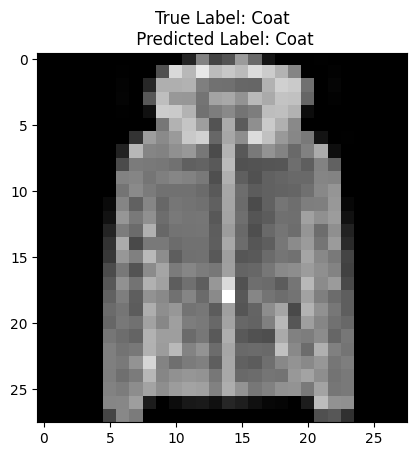

In [ ]:
m_test = X_test.shape[0]

sample_index = np.random.randint(0, m_test)
random_image = X_test[sample_index]
random_label = y_test[sample_index]

output, _, _ = Sequential(layers, random_image.reshape(1, 784))
print(output)
predicted_label = np.argmax(output)

image = random_image * 255
image = image.reshape(28, 28)

plt.imshow(image, cmap='gray')
plt.title(f"True Label: {y_labels[random_label]}\n Predicted Label: {y_labels[predicted_label]}")
plt.show()

### Tensorflow Implementation

Tensorflow is an open-source framework developed by Google Brain. It is one of the most popular libraries for building deep learning models, like the multilayer perceptron used in this notebook. Tensorflow has a rich ecosystem of tools and libraries, including Keras (a high-level API for building and training these models). Learning Tensorflow makes it easy to quickly test and use models, especially when building from scratch is not feasible, or simply not necessary.

In [ ]:
import tensorflow as tf

In [ ]:
tf_model = tf.keras.Sequential([
    tf.keras.layers.Dense(25, activation = "relu", input_shape=(784,)),
    tf.keras.layers.Dense(15, activation = "relu"),
    tf.keras.layers.Dense(10, activation = "softmax")
])

In [ ]:
tf_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 25)             │        19,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 15)             │           390 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           160 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,175 (78.81 KB)

 Trainable params: 20,175 (78.81 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
tf_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
tf_history = tf_model.fit(
    X_train,
    y_train,
    epochs=20,
    validation_data=(X_test, y_test)
)

print("Tensorflow model done training")

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6969 - loss: 0.8502 - val_accuracy: 0.8454 - val_loss: 0.4563
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8446 - loss: 0.4429 - val_accuracy: 0.8538 - val_loss: 0.4152
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8592 - loss: 0.3955 - val_accuracy: 0.8626 - val_loss: 0.3992
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8650 - loss: 0.3803 - val_accuracy: 0.8600 - val_loss: 0.3968
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8723 - loss: 0.3564 - val_accuracy: 0.8642 - val_loss: 0.3794
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8760 - loss: 0.3465 - val_accuracy: 0.8737 - val_loss: 0.3562
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.8846 - loss: 0.3249 - val_accuracy: 0.8724 - val_loss: 0.3589
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8850 - loss: 0.3198 - 

In [ ]:
tf_loss, tf_accuracy = tf_model.evaluate(X_test, y_test)
final_tf_accuracy = tf_accuracy*100
print(f"Tensorflow model accuracy: {final_tf_accuracy:.3f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8799 - loss: 0.3419
Tensorflow model accuracy: 88.120%
